# Rail Corrugation — Data Analysis (FFT / frequency domain)

**Task:** classify each 1-second axle-box recording as **Normal**, **Side I**, or **Side II**
corrugation (3-class, per-file). Each file is 10,000 samples at **10 kHz** across **128 channels**
(vibration + shock for 8 positions × 8 cars). Positions 1,3,5,7 = **Side I** rail; 2,4,6,8 = **Side II**.

**Why frequency domain?** Corrugation is a periodic wear pattern, so it excites vibration at a
*characteristic frequency* — the fault lives in the spectrum, not the raw amplitude. This notebook
uses the **Fourier transform** (Welch PSD, via SciPy) to turn each file into frequency-domain
features, checks whether they separate the classes, and diagnoses what still needs work.

Sections: (1) the FFT idea on one signal, (2) average spectra by class, (3) band-energy
separation, (4) the speed problem, (5) which features separate the classes, (6) a baseline
classifier — and the honest result, (7) findings & next steps.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import signal
sns.set_theme(style="whitegrid", context="notebook")

FS = 10_000.0                       # sampling rate (Hz)
DATA = r"/tmp/claude-0/-home-claude/bbc2252a-56af-5e7a-8fb5-5b2854f45016/scratchpad/nebulax_repo/PS3/02_Datasets/Rail_Corrugation"                    # <- set to your Rail_Corrugation folder to re-run locally
PAL = {"Normal":"#4C78A8", "Side I":"#F58518", "Side II":"#E45756"}

# features already extracted for all 272 train files (see rail_features.csv)
F = pd.read_csv("rail_features.csv")
print("feature table:", F.shape, "| classes:", F['label'].value_counts().to_dict())

feature table: (272, 51) | classes: {'Normal': 234, 'Side II': 24, 'Side I': 14}


## 1. The FFT idea, on one channel

Following the classic recipe (a signal in time → its frequencies via FFT): we take one vibration
channel from one file per class and compare the raw trace to its spectrum. The raw traces look
similar; the *spectra* are where the fault shows up.

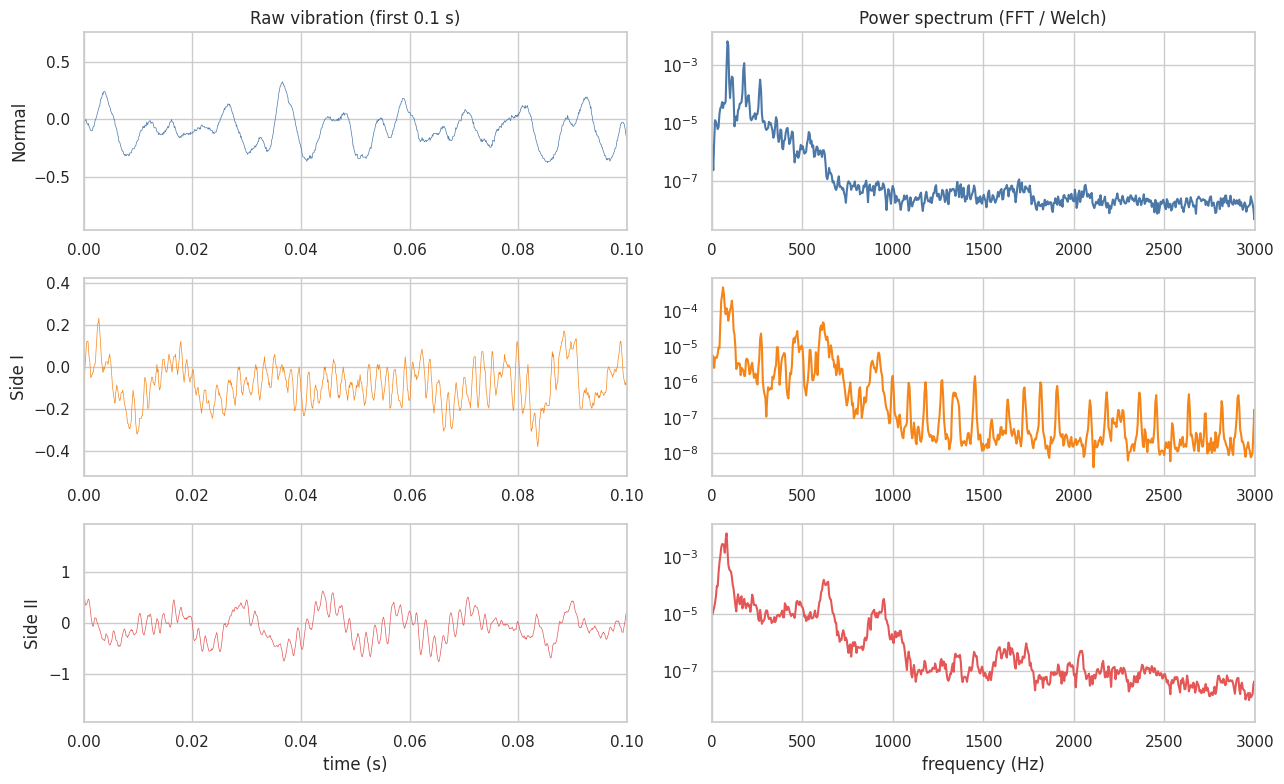

In [2]:
# column layout: col0 = speed; then car(0..7) x pos(1..8) x [vib, shock]
def vib_col(car, pos): return 1 + car*16 + (pos-1)*2
EXAMPLES = {"Normal":"Train1.csv", "Side I":"Train62.csv", "Side II":"Train2.csv"}
ch = vib_col(0, 1)   # car 1, position 1 (a Side I channel)

fig, ax = plt.subplots(3, 2, figsize=(13, 8))
for r,(lab,fn) in enumerate(EXAMPLES.items()):
    x = pd.read_csv(f"{DATA}/Train/{fn}", usecols=[ch]).values[:,0].astype(float)
    t = np.arange(len(x))/FS
    ax[r,0].plot(t, x, color=PAL[lab], lw=0.5); ax[r,0].set_ylabel(lab); ax[r,0].set_xlim(0,0.1)
    f, P = signal.welch(x-x.mean(), fs=FS, nperseg=2048)
    ax[r,1].semilogy(f, P, color=PAL[lab]); ax[r,1].set_xlim(0,3000)
ax[0,0].set_title("Raw vibration (first 0.1 s)"); ax[0,1].set_title("Power spectrum (FFT / Welch)")
ax[2,0].set_xlabel("time (s)"); ax[2,1].set_xlabel("frequency (Hz)")
plt.tight_layout(); plt.show()

## 2. Average spectrum per class

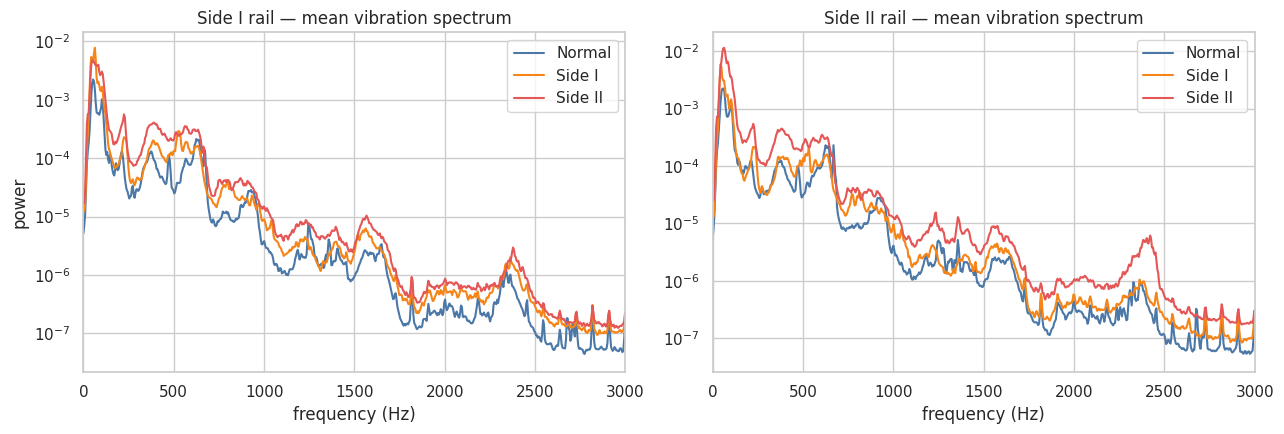

In [3]:
# average PSD across each side's vibration channels, averaged over a few files per class
def side_cols(side):
    ps=[1,3,5,7] if side=="I" else [2,4,6,8]
    return [vib_col(c,p) for c in range(8) for p in ps]

def mean_psd(files, side):
    acc=None
    for fn in files:
        x=pd.read_csv(f"{DATA}/Train/{fn}", usecols=side_cols(side)).values.astype(float)
        f,P=signal.welch(x-x.mean(0), fs=FS, nperseg=2048, axis=0); P=P.mean(1)
        acc=P if acc is None else acc+P
    return f, acc/len(files)

lab2files = {lab: F[F.label==lab].filename.head(8).tolist() for lab in PAL}
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
for si,side in enumerate(["I","II"]):
    for lab,files in lab2files.items():
        f,P=mean_psd(files, side); ax[si].semilogy(f,P,color=PAL[lab],label=lab)
    ax[si].set_xlim(0,3000); ax[si].set_title(f"Side {side} rail — mean vibration spectrum")
    ax[si].set_xlabel("frequency (Hz)"); ax[si].legend()
ax[0].set_ylabel("power")
plt.tight_layout(); plt.show()

## 3. Band-energy separation by class

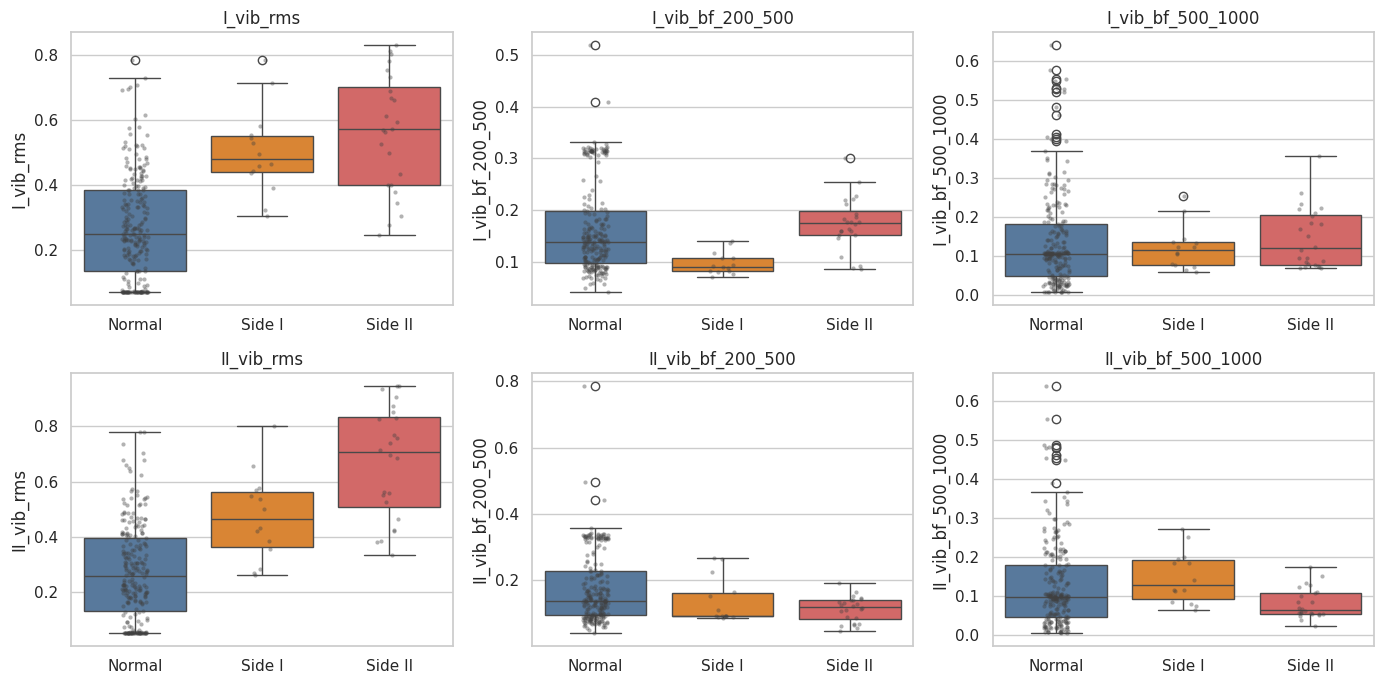

In [4]:
bands = ["I_vib_rms","I_vib_bf_200_500","I_vib_bf_500_1000",
         "II_vib_rms","II_vib_bf_200_500","II_vib_bf_500_1000"]
fig, ax = plt.subplots(2,3, figsize=(14,7))
for a,c in zip(ax.ravel(), bands):
    sns.boxplot(data=F, x="label", y=c, palette=PAL, order=list(PAL), ax=a)
    sns.stripplot(data=F, x="label", y=c, order=list(PAL), color=".25", size=3, alpha=.4, ax=a)
    a.set_title(c); a.set_xlabel("")
plt.tight_layout(); plt.show()

## 4. The speed problem

The speed sensor is a 0/1 toothed-wheel toggle; counting transitions in the 1-second window gives
a speed proxy. It varies a lot across files — and since corrugation frequency = speed ÷ wavelength,
that shifts the characteristic frequency between files. Raw band energies are therefore not directly
comparable, which motivates **order (speed) normalisation**.

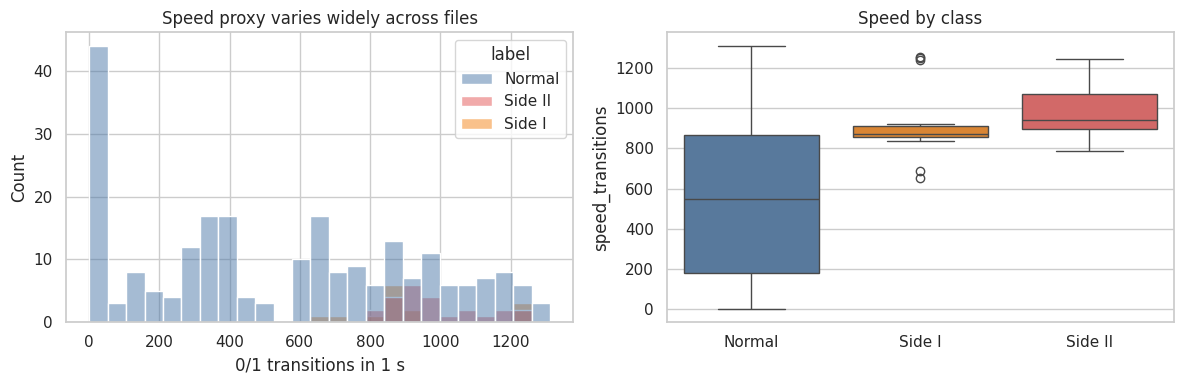

speed range: 0 - 1313 | mean 600


In [5]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.histplot(F, x="speed_transitions", hue="label", palette=PAL, bins=25, ax=ax[0])
ax[0].set_title("Speed proxy varies widely across files"); ax[0].set_xlabel("0/1 transitions in 1 s")
sns.boxplot(data=F, x="label", y="speed_transitions", palette=PAL, order=list(PAL), ax=ax[1])
ax[1].set_title("Speed by class"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()
print("speed range:", int(F.speed_transitions.min()), "-", int(F.speed_transitions.max()),
      "| mean", round(F.speed_transitions.mean()))

## 5. Which features separate the classes?

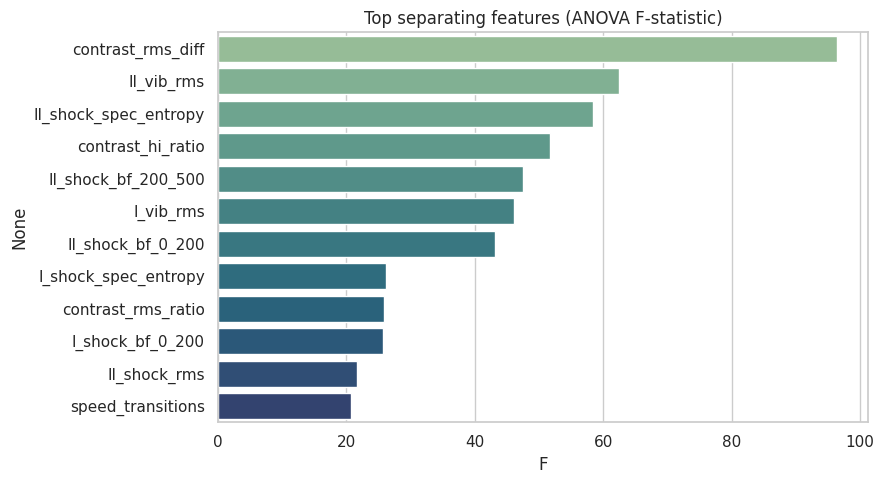

contrast_rms_diff        96.4
II_vib_rms               62.5
II_shock_spec_entropy    58.4
contrast_hi_ratio        51.6
II_shock_bf_200_500      47.5
I_vib_rms                46.1
II_shock_bf_0_200        43.2
I_shock_spec_entropy     26.1
contrast_rms_ratio       25.8
I_shock_bf_0_200         25.7
II_shock_rms             21.7
speed_transitions        20.8
dtype: float64

In [6]:
feat=[c for c in F.columns if c not in ('filename','label')]
# rank features by how much class means differ (ANOVA F-stat)
from sklearn.feature_selection import f_classif
Fval,_ = f_classif(F[feat].values, F['label'].values)
rank = pd.Series(Fval, index=feat).sort_values(ascending=False)
plt.figure(figsize=(9,5))
sns.barplot(x=rank.head(12).values, y=rank.head(12).index, palette="crest")
plt.title("Top separating features (ANOVA F-statistic)"); plt.xlabel("F"); plt.tight_layout(); plt.show()
rank.head(12).round(1)

## 6. Baseline classifier — the honest result

A RandomForest on all 49 features, 5-fold stratified CV with class weighting. This is where the
current approach shows its real strengths and its one big gap.

macro F1: 0.548
              precision    recall  f1-score   support

      Normal       0.91      0.99      0.94       234
      Side I       0.00      0.00      0.00        14
     Side II       0.88      0.58      0.70        24

    accuracy                           0.90       272
   macro avg       0.59      0.52      0.55       272
weighted avg       0.86      0.90      0.87       272



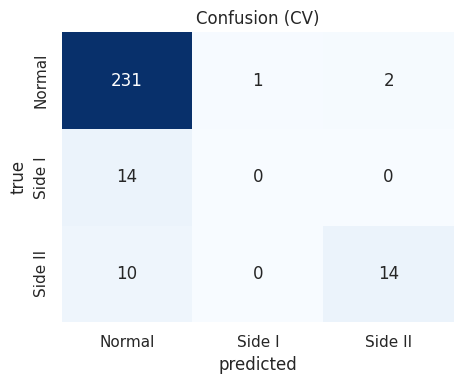

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
X=F[feat].values; y=F['label'].values
rf=RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample",
                          min_samples_leaf=1, random_state=0)
yp=cross_val_predict(rf, X, y, cv=StratifiedKFold(5,shuffle=True,random_state=0))
print("macro F1:", round(f1_score(y,yp,average='macro'),3))
print(classification_report(y,yp,digits=2))
cm=confusion_matrix(y,yp,labels=list(PAL))
plt.figure(figsize=(4.8,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,xticklabels=list(PAL),yticklabels=list(PAL))
plt.ylabel("true"); plt.xlabel("predicted"); plt.title("Confusion (CV)"); plt.tight_layout(); plt.show()

## 7. Outlier & Side I diagnosis — why the rare class is missed

Before modelling, we asked *why* Side I gets 0.00 F1. The answer isn't outliers or bad labels — it's
that the 14 Side I files **hide inside the Normal cloud** on our current features. The table below
shows how much of Side I falls within Normal's ordinary 5–95% range: if it's near 100%, that feature
cannot tell them apart.

In [ ]:
key=["I_vib_rms","II_vib_rms","contrast_rms_ratio","I_vib_bf_500_1000","contrast_hi_ratio"]
rows=[]
for c in key:
    nlo,nhi=F[F.label=="Normal"][c].quantile([.05,.95])
    s1=F[F.label=="Side I"][c]
    rows.append({"feature":c, "Normal 5-95% band":f"[{nlo:.2f}, {nhi:.2f}]",
                 "Side I median":round(s1.median(),2),
                 "% Side I inside Normal":f"{((s1>=nlo)&(s1<=nhi)).mean():.0%}"})
print("Side I overlap with Normal (higher % = less separable):")
pd.DataFrame(rows)

Side I overlap with Normal (higher % = less separable):


,feature,Normal 5-95% band,Side I median,% Side I inside Normal
0,I_vib_rms,"[0.07, 0.54]",0.48,64%
1,II_vib_rms,"[0.05, 0.57]",0.47,71%
2,contrast_rms_ratio,"[0.85, 1.33]",1.08,93%
3,I_vib_bf_500_1000,"[0.01, 0.40]",0.12,100%
4,contrast_hi_ratio,"[0.79, 1.52]",0.93,71%


**Per-feature separability confirms it.** Using AUC (0.5 = useless, 1.0 = perfect), we compare
how well each feature separates each fault class from Normal. Side II separates cleanly; Side I does
not — and its best feature (`I_vib_rms`) also fires for Side II, so it can't identify Side I *specifically*.

In [ ]:
from sklearn.metrics import roc_auc_score
def best_aucs(pos):
    sub=F[F.label.isin(["Normal",pos])]; yb=(sub.label==pos).astype(int)
    a={c:max(roc_auc_score(yb,sub[c]),roc_auc_score(yb,-sub[c])) for c in feat}
    return pd.Series(a).sort_values(ascending=False)
cmp=pd.DataFrame({"Side I vs Normal":best_aucs("Side I").head(6),
                  "Side II vs Normal":best_aucs("Side II").reindex(best_aucs("Side I").head(6).index)}).round(3)
print("best Side I AUC:", round(best_aucs("Side I").max(),3),
      "| best Side II AUC:", round(best_aucs("Side II").max(),3))
cmp

best Side I AUC: 0.871 | best Side II AUC: 0.929


,Side I vs Normal,Side II vs Normal
I_vib_rms,0.871,0.879
I_shock_bf_0_200,0.815,0.827
I_shock_spec_entropy,0.814,0.810
II_vib_rms,0.806,0.929
I_vib_spec_entropy,0.779,0.597
speed_transitions,0.777,0.823


**Multivariate outliers (IsolationForest).** The fault classes have a higher outlier rate, but
most Side  files are *not* flagged as outliers — they look ordinary, which is exactly the problem.
And only one Normal file is a genuine energy outlier, so there's no mislabel goldmine to exploit.

outlier rate by class: {'Normal': 0.09, 'Side I': 0.21, 'Side II': 0.21}


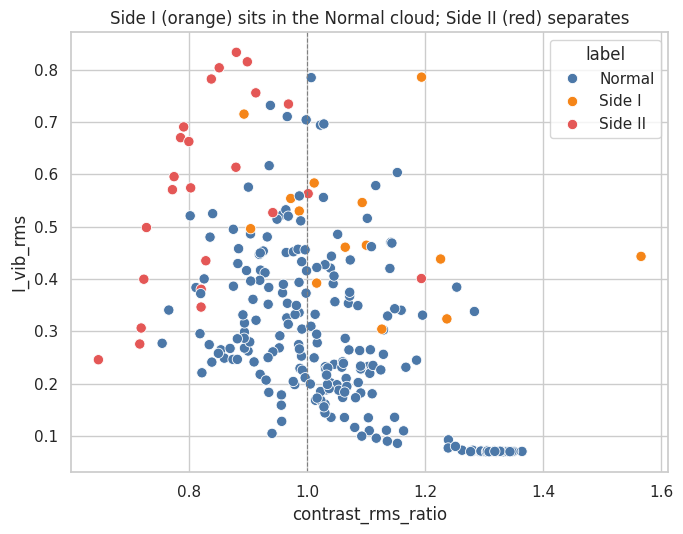

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
Xs=StandardScaler().fit_transform(F[feat].fillna(0).values)
F["is_outlier"]=IsolationForest(contamination=0.1,random_state=0).fit_predict(Xs)==-1
print("outlier rate by class:", F.groupby("label")["is_outlier"].mean().round(2).to_dict())

# visual: Side I overlaps Normal; Side II pulls away
plt.figure(figsize=(7,5.5))
sns.scatterplot(data=F, x="contrast_rms_ratio", y="I_vib_rms", hue="label",
                palette=PAL, hue_order=list(PAL), s=55, edgecolor="w")
plt.axvline(1.0, color="gray", ls="--", lw=0.8)
plt.title("Side I (orange) sits in the Normal cloud; Side II (red) separates")
plt.tight_layout(); plt.show()

**What this means for the plan:** Side I fails for a *feature* reason, not an imbalance or
outlier reason — so SMOTE / class weights alone won't rescue it (you can't oversample classes that
overlap). The fix is feature engineering: **per-car / max-over-channel features** (so a fault on a
few cars isn't averaged away) and **order normalisation + envelope spectrum** (so Side I's
characteristic frequency shows up even when gross energy looks normal).

## 8. Findings & next steps

**What works:** FFT / frequency-domain features cleanly detect **Normal** (~0.94 F1) and pick up
**Side II** (~0.70). The strongest features are the **side-contrast** ones (Side I vs Side II RMS
ratio/difference) and the mid-band vibration energy — physically sensible, since corrugation adds
energy on the affected side.

**The gap — Side I (only 14 files) is missed.** Two likely reasons, both fixable:
1. **No speed normalisation yet.** Speed ranges ~0–1300; the corrugation frequency moves with it,
   smearing the band features. Next: estimate speed from the toothed-wheel signal and resample to a
   fixed *order* axis (frequency ÷ rotation rate) before taking the PSD.
2. **Averaging over 32 channels per side dilutes a localised fault.** A Side I fault may sit on
   specific cars/positions; the per-side mean washes it out. Next: keep per-car or max-over-channel
   features, and add an **envelope spectrum** (classic for impact/bearing faults).
3. **Extreme imbalance** (14 vs 234). Next: try SMOTE / focal-style weighting, and report macro-F1
   (the info kit's metric) rather than accuracy.

So: **yes, FFT is the right foundation** — it already solves 2 of 3 classes. The modelling work is
squarely about rescuing Side I via order normalisation + localised (per-car/envelope) features +
imbalance handling.